# notebook 01 (redo) - EDA / data visualisation

Redoing the data exploration in one clean notebook since data visualisation is the first step Dr Talebi asked for.

5 cities (Jena, London, New York, Sydney, Tokyo), hourly weather from Open-Meteo, 2000-2009.
Runs on Kaggle (dataset: multi-city-weather-2000-2009) or locally on my laptop.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [2]:
# running on kaggle or locally?
if os.path.exists('/kaggle/input'):
    DATA_PATH = '/kaggle/input/multi-city-weather-2000-2009/'
    OUT = '/kaggle/working/'
else:
    DATA_PATH = 'D:/Final year project/Dataset/'
    OUT = 'D:/Final year project/'

PLOTS = OUT + 'plots/'
os.makedirs(PLOTS, exist_ok=True)
print(DATA_PATH)

D:/Final year project/Dataset/


## load the 5 city csvs

In [3]:
city_files = {
    'Jena':     'jena_germany_2000_2009_hourly.csv',
    'London':   'london_uk_2000_2009_hourly.csv',
    'New_York': 'newyork_usa_2000_2009_hourly.csv',
    'Sydney':   'sydney_australia_2000_2009_hourly.csv',
    'Tokyo':    'tokyo_japan_2000_2009_hourly.csv',
}

# keeping the same coords as before so the processed csv stays identical
city_coords = {
    'Jena':     (50.9272, 11.5861),
    'London':   (51.5074, -0.1278),
    'New_York': (40.7128, -74.0060),
    'Sydney':   (-33.8688, 151.2093),
    'Tokyo':    (35.6762, 139.6503),
}

# first 3 rows of each csv are open-meteo metadata (lat/lon/elevation), real header is row 4
dfs = {}
for city, fname in city_files.items():
    df = pd.read_csv(DATA_PATH + fname, skiprows=3, low_memory=False)
    # strip units off the column names, the degree symbol kept causing encoding headaches
    df.columns = [c.split(' (')[0] for c in df.columns]
    df['time'] = pd.to_datetime(df['time'])
    df['city'] = city
    df['lat'], df['lon'] = city_coords[city]
    dfs[city] = df
    print(city, df.shape)

Jena (87672, 25)


London (87672, 25)


New_York (87672, 25)


Sydney (87672, 25)


Tokyo (87672, 25)


In [4]:
# shorter names so I dont have to type temperature_2m everywhere
short_names = {
    'temperature_2m': 'temperature',
    'relative_humidity_2m': 'humidity',
    'dew_point_2m': 'dew_point',
    'wind_speed_10m': 'wind_speed',
    'wind_direction_10m': 'wind_direction',
    'wind_gusts_10m': 'wind_gusts',
    'et0_fao_evapotranspiration': 'evapotranspiration',
    'soil_temperature_0_to_7cm': 'soil_temperature',
    'wet_bulb_temperature_2m': 'wet_bulb_temp',
    'total_column_integrated_water_vapour': 'water_vapour',
}
for city in dfs:
    dfs[city] = dfs[city].rename(columns=short_names)

list(dfs['Jena'].columns)

['time',
 'temperature',
 'humidity',
 'dew_point',
 'precipitation',
 'rain',
 'wind_speed',
 'wind_direction',
 'wind_gusts',
 'pressure_msl',
 'surface_pressure',
 'cloud_cover',
 'cloud_cover_low',
 'cloud_cover_mid',
 'cloud_cover_high',
 'evapotranspiration',
 'vapour_pressure_deficit',
 'soil_temperature',
 'wet_bulb_temp',
 'water_vapour',
 'shortwave_radiation',
 'direct_radiation',
 'city',
 'lat',
 'lon']

In [5]:
dfs['Jena'].head()

,time,temperature,humidity,dew_point,precipitation,rain,wind_speed,wind_direction,wind_gusts,pressure_msl,surface_pressure,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,evapotranspiration,vapour_pressure_deficit,soil_temperature,wet_bulb_temp,water_vapour,shortwave_radiation,direct_radiation,city,lat,lon
0,2000-01-01 00:00:00,-1.5,92,-2.7,0.0,0.0,6.4,196,10.1,1024.7,1004.5,74,72,2,1,0.0,0.05,2.0,-2.3,8.3,0.0,0.0,Jena,50.9272,11.5861
1,2000-01-01 01:00:00,-1.8,92,-2.9,0.0,0.0,5.4,200,10.1,1025.1,1004.8,67,66,0,0,0.0,0.04,1.8,-2.5,8.5,0.0,0.0,Jena,50.9272,11.5861
2,2000-01-01 02:00:00,-1.4,92,-2.6,0.0,0.0,6.3,204,10.4,1024.6,1004.4,78,77,0,0,0.0,0.04,1.8,-2.2,8.7,0.0,0.0,Jena,50.9272,11.5861
3,2000-01-01 03:00:00,-1.8,92,-2.9,0.0,0.0,6.0,197,10.1,1024.5,1004.2,68,66,2,0,0.0,0.04,1.8,-2.6,8.8,0.0,0.0,Jena,50.9272,11.5861
4,2000-01-01 04:00:00,-2.1,93,-3.1,0.0,0.0,6.3,193,10.4,1024.8,1004.5,75,74,2,0,0.0,0.04,1.7,-2.8,9.1,0.0,0.0,Jena,50.9272,11.5861


In [6]:
dfs['Jena'].describe().T.round(2)

,count,mean,min,25%,50%,75%,max,std
time,87672,2004-12-31 11:30:00,2000-01-01 00:00:00,2002-07-02 05:45:00,2004-12-31 11:30:00,2007-07-02 17:15:00,2009-12-31 23:00:00,NaN
temperature,87672.0,10.070671,-19.7,4.0,10.1,16.0,34.3,7.922755
humidity,87672.0,76.986769,21.0,67.0,80.0,89.0,100.0,14.856892
dew_point,87672.0,5.842633,-23.2,1.3,6.2,10.9,22.1,6.623891
precipitation,87672.0,0.07308,0.0,0.0,0.0,0.0,9.3,0.270298
rain,87672.0,0.06724,0.0,0.0,0.0,0.0,9.3,0.264345
wind_speed,87672.0,11.594692,0.0,7.0,10.2,15.2,50.7,6.154924
wind_direction,87672.0,198.693699,1.0,126.0,223.0,264.0,360.0,90.823924
wind_gusts,87672.0,25.015705,2.2,14.4,22.3,32.4,129.6,13.280984
pressure_msl,87672.0,1016.321505,971.6,1010.8,1016.5,1022.2,1047.8,9.147829


## missing values

In [7]:
for city, df in dfs.items():
    n = df.isna().sum().sum()
    print(f'{city}: {n} missing cells out of {df.size}')

Jena: 0 missing cells out of 2191800
London: 0 missing cells out of 2191800
New_York: 0 missing cells out of 2191800
Sydney: 0 missing cells out of 2191800
Tokyo: 0 missing cells out of 2191800


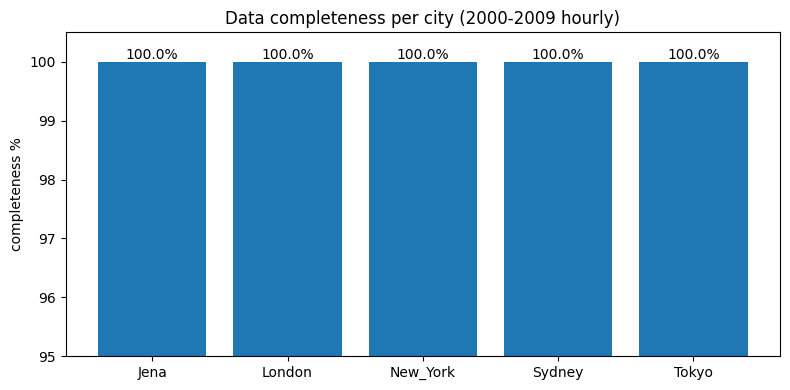

In [8]:
# bar chart of completeness, all 5 should sit at 100%
comp = {c: 100 * (1 - df.isna().sum().sum() / df.size) for c, df in dfs.items()}

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(comp.keys(), comp.values())
ax.set_ylim(95, 100.5)
ax.set_ylabel('completeness %')
ax.set_title('Data completeness per city (2000-2009 hourly)')
for i, v in enumerate(comp.values()):
    ax.text(i, v, f'{v:.1f}%', ha='center', va='bottom')
plt.tight_layout()
plt.savefig(PLOTS + 'eda_completeness.png', dpi=150)
plt.show()

## temperature - basic stats

Temperature is the forecast target so it gets most of the attention here.

In [9]:
stats = pd.DataFrame({city: df['temperature'].agg(['min', 'mean', 'max', 'std'])
                      for city, df in dfs.items()}).T.round(2)
stats

,min,mean,max,std
Jena,-19.7,10.07,34.3,7.92
London,-7.8,10.80,34.7,5.98
New_York,-20.7,11.58,37.4,10.14
Sydney,3.3,17.34,38.1,4.64
Tokyo,-9.1,14.78,37.0,8.43


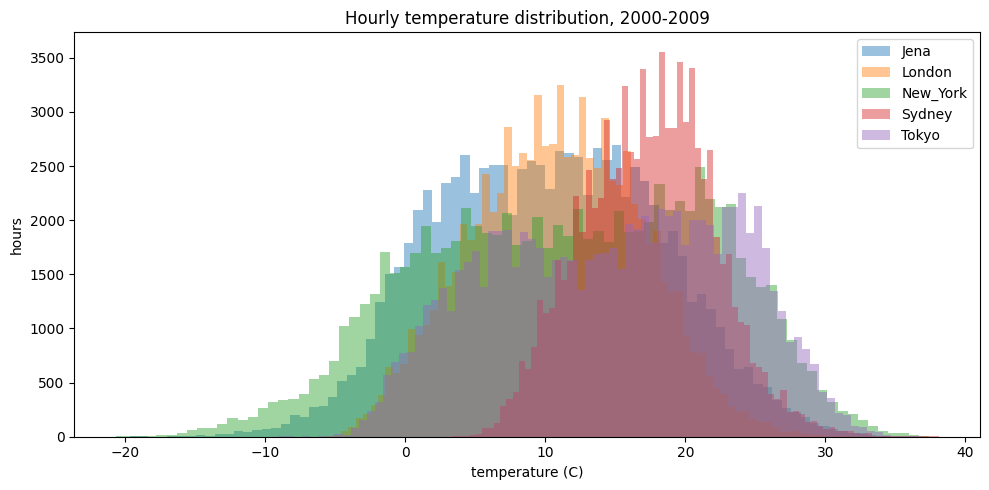

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
for city, df in dfs.items():
    ax.hist(df['temperature'], bins=80, alpha=0.45, label=city)
ax.set_xlabel('temperature (C)')
ax.set_ylabel('hours')
ax.set_title('Hourly temperature distribution, 2000-2009')
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS + 'eda_temperature_distributions.png', dpi=150)
plt.show()

## seasonality

The monthly pattern is where the cities really differ. Sydney is southern hemisphere so its seasons are flipped vs the other four.

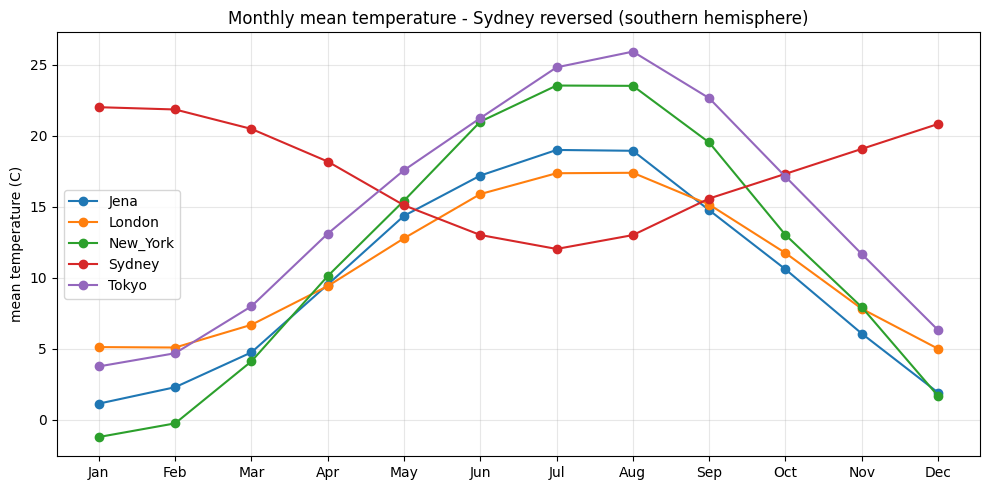

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
for city, df in dfs.items():
    monthly = df.groupby(df['time'].dt.month)['temperature'].mean()
    ax.plot(monthly.index, monthly.values, marker='o', label=city)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_ylabel('mean temperature (C)')
ax.set_title('Monthly mean temperature - Sydney reversed (southern hemisphere)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS + 'eda_monthly_patterns.png', dpi=150)
plt.show()

# this flip is the main reason a single pooled model might struggle -> RQ2 per-city vs pooled

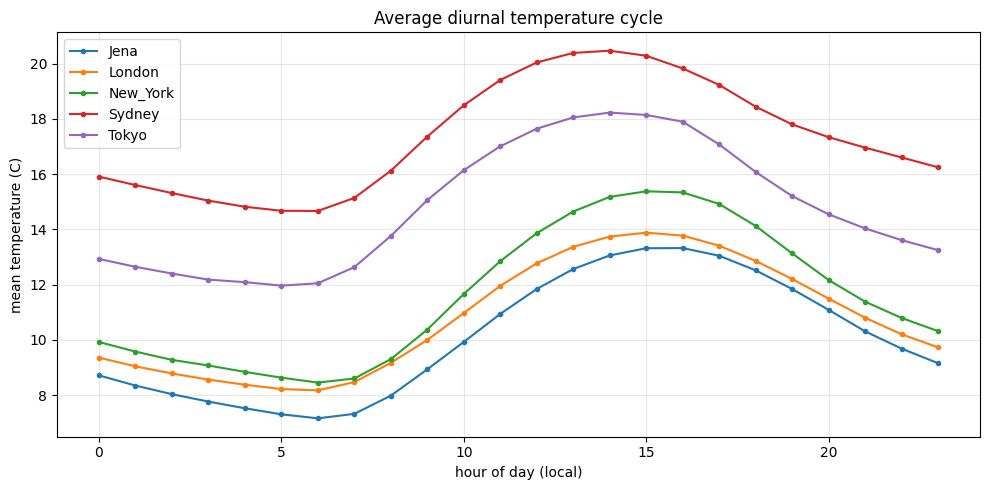

In [12]:
# diurnal cycle. timestamps are local time per city so every city should peak mid afternoon
# decent sanity check that the timezone handling in the download was right
fig, ax = plt.subplots(figsize=(10, 5))
for city, df in dfs.items():
    hourly = df.groupby(df['time'].dt.hour)['temperature'].mean()
    ax.plot(hourly.index, hourly.values, marker='.', label=city)
ax.set_xlabel('hour of day (local)')
ax.set_ylabel('mean temperature (C)')
ax.set_title('Average diurnal temperature cycle')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS + 'eda_diurnal_cycle.png', dpi=150)
plt.show()

## raw signal up close

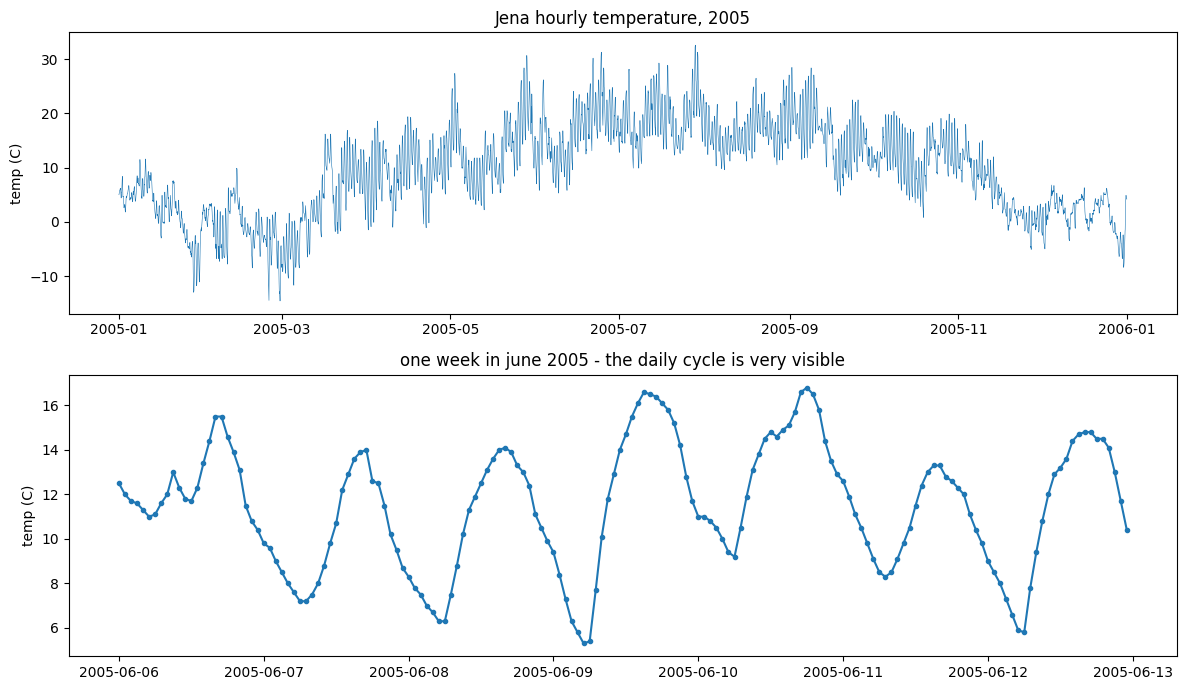

In [13]:
jena = dfs['Jena']
yr = jena[jena['time'].dt.year == 2005]
wk = jena[(jena['time'] >= '2005-06-06') & (jena['time'] < '2005-06-13')]

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
axes[0].plot(yr['time'], yr['temperature'], linewidth=0.4)
axes[0].set_title('Jena hourly temperature, 2005')
axes[1].plot(wk['time'], wk['temperature'], marker='.')
axes[1].set_title('one week in june 2005 - the daily cycle is very visible')
for a in axes:
    a.set_ylabel('temp (C)')
plt.tight_layout()
plt.savefig(PLOTS + 'eda_raw_signal_jena.png', dpi=150)
plt.show()

## autocorrelation - how much history matters

The models use a 168 hour (1 week) encoder window. Checking the autocorrelation to see if that's actually justified.

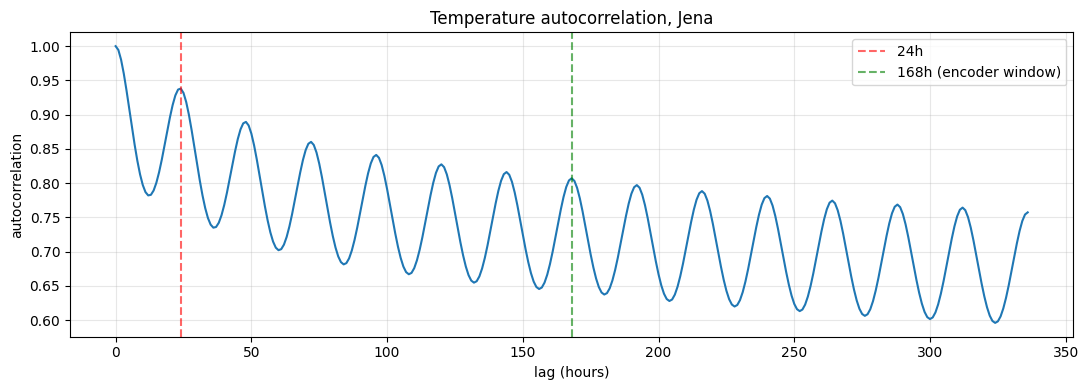

In [14]:
temp = dfs['Jena']['temperature']
lags = range(0, 14 * 24 + 1)
acf = [temp.autocorr(lag=l) for l in lags]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(lags, acf)
ax.axvline(24, color='red', linestyle='--', alpha=0.6, label='24h')
ax.axvline(168, color='green', linestyle='--', alpha=0.6, label='168h (encoder window)')
ax.set_xlabel('lag (hours)')
ax.set_ylabel('autocorrelation')
ax.set_title('Temperature autocorrelation, Jena')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS + 'eda_autocorrelation.png', dpi=150)
plt.show()

# the little bumps every 24h are the daily cycle showing up in the correlation

## relationships between features

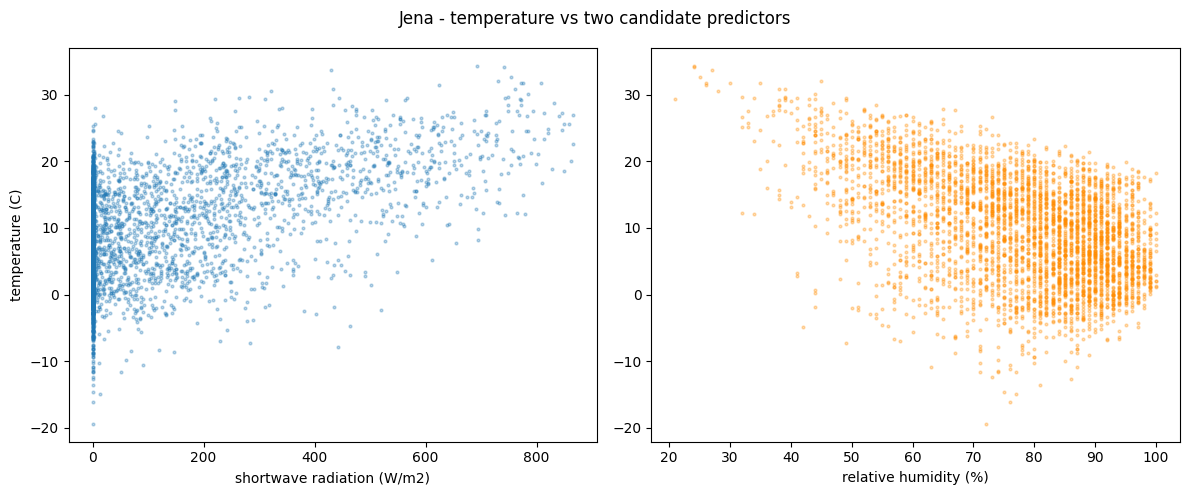

In [15]:
# scatter on a random sample, plotting all 87k points is just a blob
samp = dfs['Jena'].sample(4000, random_state=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(samp['shortwave_radiation'], samp['temperature'], s=4, alpha=0.3)
axes[0].set_xlabel('shortwave radiation (W/m2)')
axes[0].set_ylabel('temperature (C)')
axes[1].scatter(samp['humidity'], samp['temperature'], s=4, alpha=0.3, color='darkorange')
axes[1].set_xlabel('relative humidity (%)')
fig.suptitle('Jena - temperature vs two candidate predictors')
plt.tight_layout()
plt.savefig(PLOTS + 'eda_scatter_predictors.png', dpi=150)
plt.show()

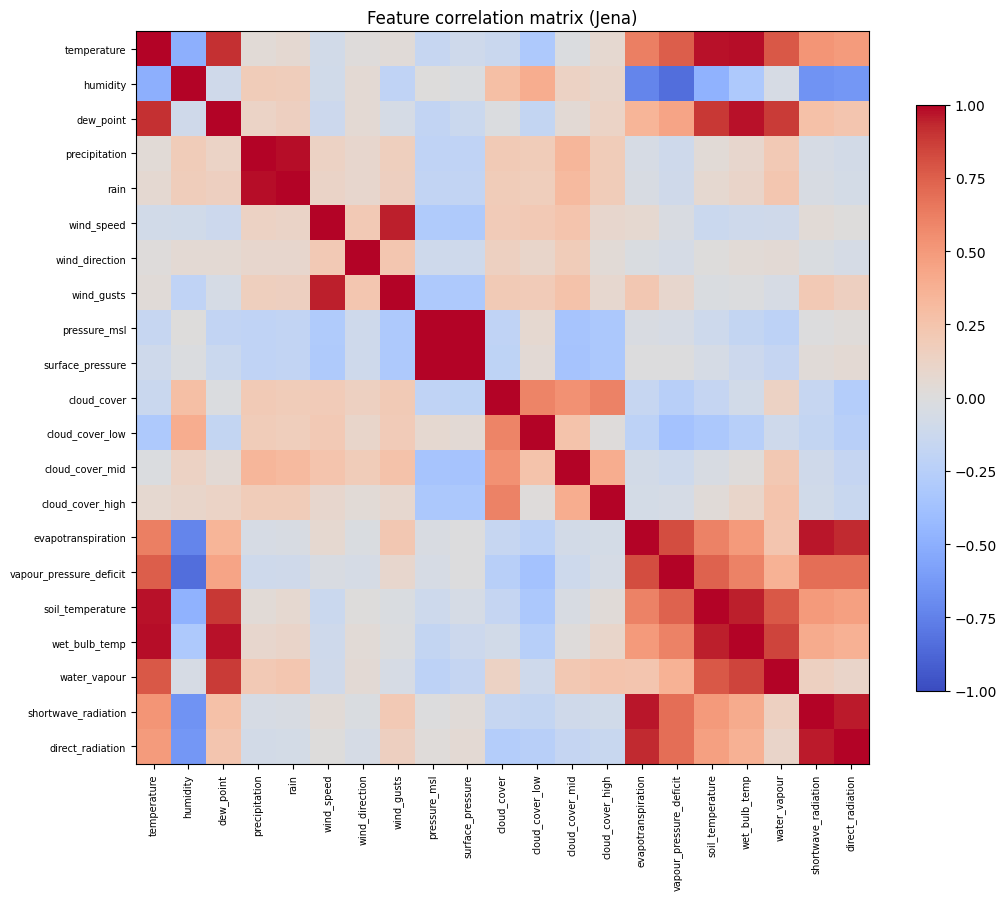

In [16]:
# full correlation matrix for jena
num = dfs['Jena'].select_dtypes(include=[np.number]).drop(columns=['lat', 'lon'])
corr = num.corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns, fontsize=7)
fig.colorbar(im, shrink=0.8)
ax.set_title('Feature correlation matrix (Jena)')
plt.tight_layout()
plt.savefig(PLOTS + 'eda_correlation_jena.png', dpi=150)
plt.show()

# dew point / wet bulb / soil temp all correlate heavily with temperature as expected

## train / val / test split

Chronological 70/15/15, same as the modelling notebooks. Never shuffle time series.

train until 2007-01-01 02:00:00
val until   2008-07-02 01:00:00


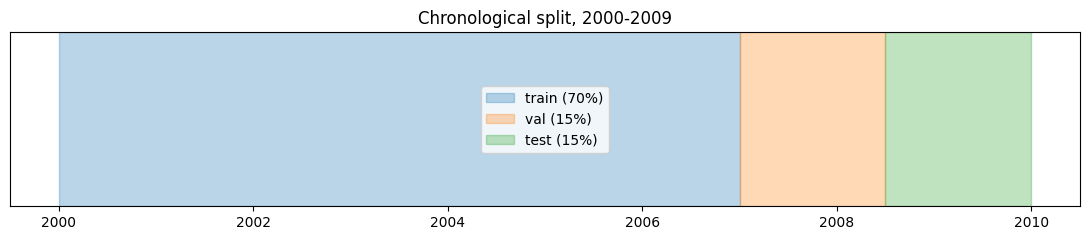

In [17]:
n = len(jena)
t = jena['time'].reset_index(drop=True)
train_end = t[int(n * 0.70)]
val_end = t[int(n * 0.85)]
print('train until', train_end)
print('val until  ', val_end)

fig, ax = plt.subplots(figsize=(11, 2.5))
ax.axvspan(t.iloc[0], train_end, alpha=0.3, color='tab:blue', label='train (70%)')
ax.axvspan(train_end, val_end, alpha=0.3, color='tab:orange', label='val (15%)')
ax.axvspan(val_end, t.iloc[-1], alpha=0.3, color='tab:green', label='test (15%)')
ax.set_yticks([])
ax.set_title('Chronological split, 2000-2009')
ax.legend(loc='center')
plt.tight_layout()
plt.savefig(PLOTS + 'eda_split_timeline.png', dpi=150)
plt.show()

## feature engineering

Same engineered features the modelling notebooks already expect, kept identical so nothing downstream breaks.

In [18]:
def engineer_features(df):
    df = df.copy()

    df['hour'] = df['time'].dt.hour
    df['month'] = df['time'].dt.month
    df['dayofyear'] = df['time'].dt.dayofyear
    df['dayofweek'] = df['time'].dt.dayofweek
    df['year'] = df['time'].dt.year

    # cyclical encoding so the model knows hour 23 is next to hour 0
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['dayofyear_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365)
    df['dayofyear_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365)

    # wind as u/v components instead of speed + direction
    wind_rad = np.deg2rad(df['wind_direction'])
    df['wind_u'] = -df['wind_speed'] * np.sin(wind_rad)
    df['wind_v'] = -df['wind_speed'] * np.cos(wind_rad)

    # lags and rolling means of the target
    df['temp_lag_1h'] = df['temperature'].shift(1)
    df['temp_lag_3h'] = df['temperature'].shift(3)
    df['temp_lag_6h'] = df['temperature'].shift(6)
    df['temp_lag_24h'] = df['temperature'].shift(24)
    df['temp_roll_6h'] = df['temperature'].rolling(6).mean()
    df['temp_roll_24h'] = df['temperature'].rolling(24).mean()
    df['temp_diff_1h'] = df['temperature'].diff(1)

    return df

In [19]:
# engineer per city (so lags dont leak across cities), then stack into one master table
master = pd.concat([engineer_features(df) for df in dfs.values()], ignore_index=True)
master = master.sort_values(['city', 'time']).reset_index(drop=True)

# first 24h per city have NaN lags, drop them
master_clean = master.dropna(subset=['temp_lag_24h', 'temp_roll_24h']).reset_index(drop=True)

os.makedirs(OUT + 'processed', exist_ok=True)
master_clean.to_csv(OUT + 'processed/master_all_cities.csv', index=False)
print(master_clean.shape)
master_clean['city'].value_counts()

(438240, 45)


city
Jena        87648
London      87648
New_York    87648
Sydney      87648
Tokyo       87648
Name: count, dtype: int64

## cross-city comparison

Going a bit deeper here since the whole per-city vs pooled question (RQ2) hinges on how different these 5 cities actually are. If they all behaved the same a pooled model would obviously be fine. Let me quantify the diversity properly instead of just eyeballing the seasonality plot.

In [20]:
# pull together a climate summary so the differences are in numbers not just plots
rows = []
for city, df in dfs.items():
    t = df['temperature']
    # annual range = mean of warmest month minus mean of coldest month
    monthly = df.groupby(df['time'].dt.month)['temperature'].mean()
    rows.append({
        'city': city,
        'mean_temp': round(t.mean(), 1),
        'std_temp': round(t.std(), 1),
        'min': t.min(),
        'max': t.max(),
        'annual_range': round(monthly.max() - monthly.min(), 1),
        'mean_humidity': round(df['humidity'].mean(), 0),
        'annual_precip_mm': round(df['precipitation'].sum() / 10, 0),  # 10 years of hourly mm
        'mean_wind': round(df['wind_speed'].mean(), 1),
    })

summary = pd.DataFrame(rows).set_index('city')
summary

,mean_temp,std_temp,min,max,annual_range,mean_humidity,annual_precip_mm,mean_wind
city,,,,,,,,
Jena,10.1,7.9,-19.7,34.3,17.9,77.0,641.0,11.6
London,10.8,6.0,-7.8,34.7,12.4,80.0,656.0,14.6
New_York,11.6,10.1,-20.7,37.4,24.8,71.0,1125.0,11.4
Sydney,17.3,4.6,3.3,38.1,10.0,70.0,596.0,10.5
Tokyo,14.8,8.4,-9.1,37.0,22.2,76.0,1450.0,11.9


### climatology fingerprints (month x hour)

This is the plot I like best. For each city, average temperature in every month-by-hour bucket. It gives a kind of fingerprint of the local climate - you can see at a glance how the daily cycle changes through the year, and the cities look completely different from each other.

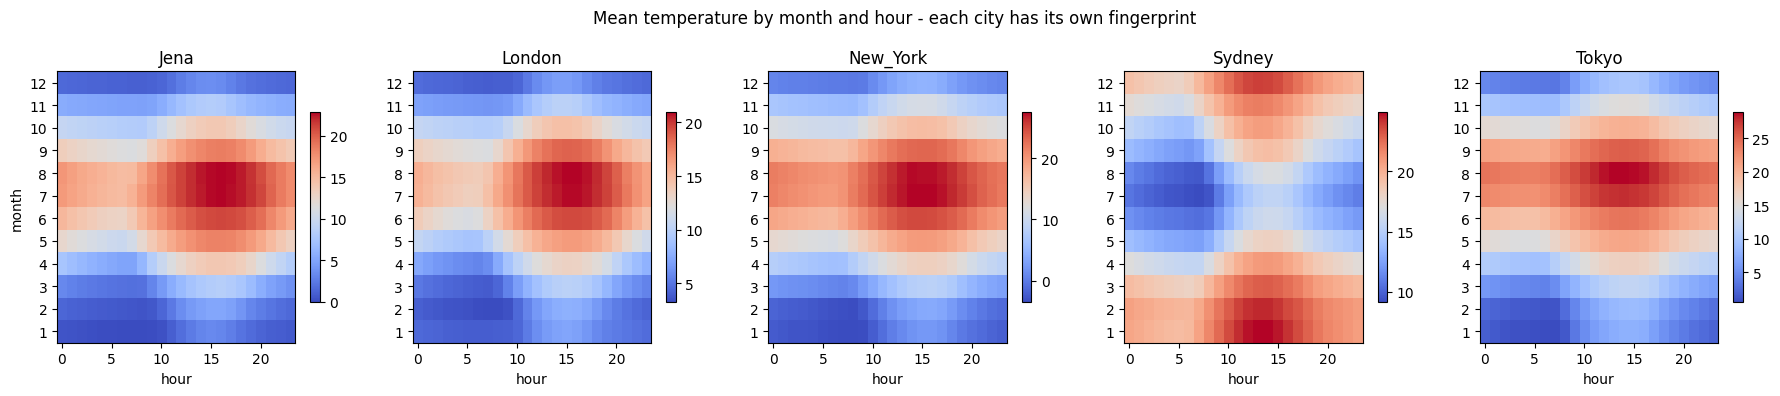

In [21]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, (city, df) in zip(axes, dfs.items()):
    piv = df.pivot_table(index=df['time'].dt.month,
                         columns=df['time'].dt.hour,
                         values='temperature', aggfunc='mean')
    im = ax.imshow(piv.values, aspect='auto', origin='lower', cmap='coolwarm')
    ax.set_title(city)
    ax.set_xlabel('hour')
    ax.set_yticks(range(0, 12))
    ax.set_yticklabels(range(1, 13))
    if city == 'Jena':
        ax.set_ylabel('month')
    fig.colorbar(im, ax=ax, shrink=0.7)
fig.suptitle('Mean temperature by month and hour - each city has its own fingerprint')
plt.tight_layout()
plt.savefig(PLOTS + 'eda_climatology_heatmaps.png', dpi=150)
plt.show()

# sydney is the obvious odd one out - warm band sits at the top/bottom not the middle

### are the cities correlated?

If the daily temperatures move together a pooled model can borrow strength across cities. If they don't (especially Sydney being flipped) then per-city models might make more sense. Resampling to daily mean temperature and correlating across cities.

(3653, 5)
          Jena  London  New_York  Sydney  Tokyo
Jena      1.00    0.90      0.82   -0.77   0.84
London    0.90    1.00      0.81   -0.76   0.84
New_York  0.82    0.81      1.00   -0.80   0.88
Sydney   -0.77   -0.76     -0.80    1.00  -0.82
Tokyo     0.84    0.84      0.88   -0.82   1.00


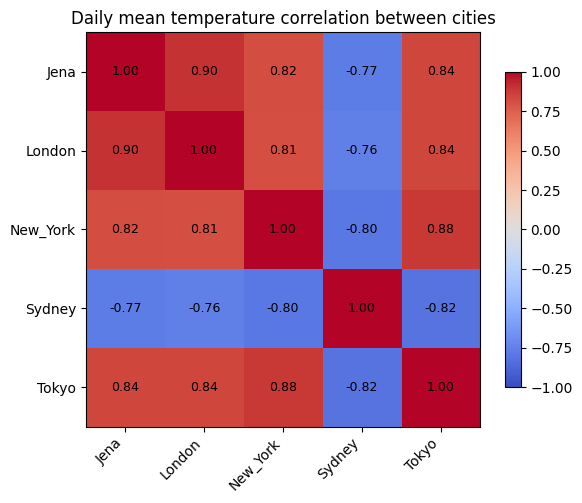

In [22]:
# daily mean temp per city, lined up on the same dates
daily = {}
for city, df in dfs.items():
    s = df.set_index('time')['temperature'].resample('D').mean()
    daily[city] = s
daily = pd.DataFrame(daily)
print(daily.shape)

city_corr = daily.corr()
print(city_corr.round(2))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(city_corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(5)); ax.set_xticklabels(city_corr.columns, rotation=45, ha='right')
ax.set_yticks(range(5)); ax.set_yticklabels(city_corr.columns)
# write the numbers in the cells
for i in range(5):
    for j in range(5):
        ax.text(j, i, f'{city_corr.values[i, j]:.2f}', ha='center', va='center', fontsize=9)
fig.colorbar(im, shrink=0.8)
ax.set_title('Daily mean temperature correlation between cities')
plt.tight_layout()
plt.savefig(PLOTS + 'eda_intercity_correlation.png', dpi=150)
plt.show()

# jena/london/tokyo/ny all positive together, sydney goes negative against them. exactly the flip.

### long term trend and precipitation

Two more quick ones. First, is there any warming drift across the 10 years (would matter for the chronological split, since test is the last 15%). Second, precipitation regimes - another axis where the cities differ.

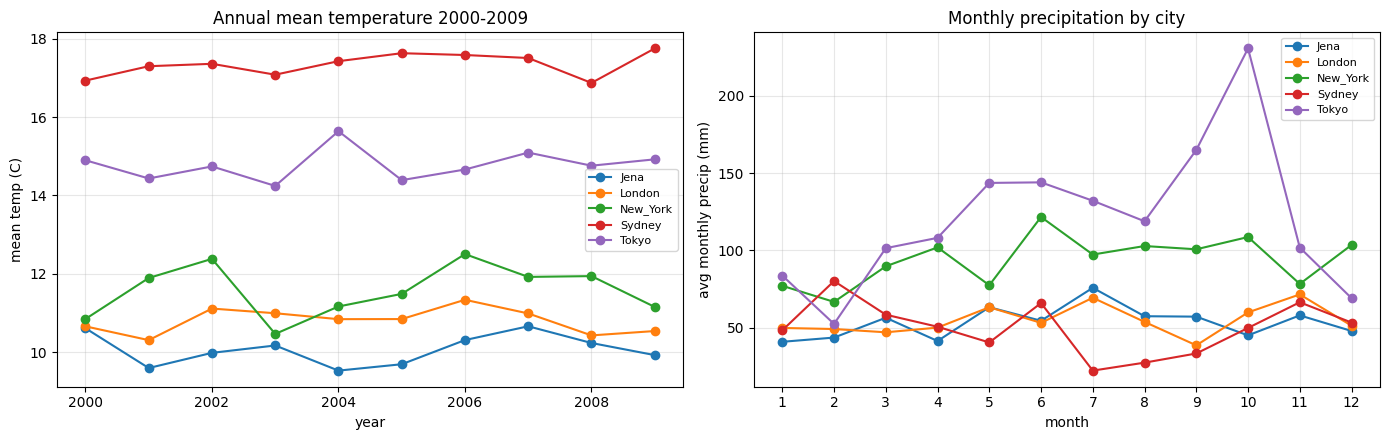

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# annual mean temperature per city
for city, df in dfs.items():
    yearly = df.groupby(df['time'].dt.year)['temperature'].mean()
    axes[0].plot(yearly.index, yearly.values, marker='o', label=city)
axes[0].set_xlabel('year')
axes[0].set_ylabel('mean temp (C)')
axes[0].set_title('Annual mean temperature 2000-2009')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# average monthly precipitation per city (mean monthly total across the 10 years)
for city, df in dfs.items():
    # total precip each month of each year, then average over years
    mp = df.groupby([df['time'].dt.year, df['time'].dt.month])['precipitation'].sum()
    mp = mp.groupby(level=1).mean()
    axes[1].plot(mp.index, mp.values, marker='o', label=city)
axes[1].set_xticks(range(1, 13))
axes[1].set_xlabel('month')
axes[1].set_ylabel('avg monthly precip (mm)')
axes[1].set_title('Monthly precipitation by city')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS + 'eda_trend_and_precip.png', dpi=150)
plt.show()

# no strong warming trend over just 10 years. tokyo clearly has a wet summer monsoon-ish pattern.

### wind rose per city

Finally getting to the wind rose I left as a TODO last time. Binning wind direction into 16 compass sectors and showing how often the wind blows from each. Prevailing wind direction is pretty different city to city.

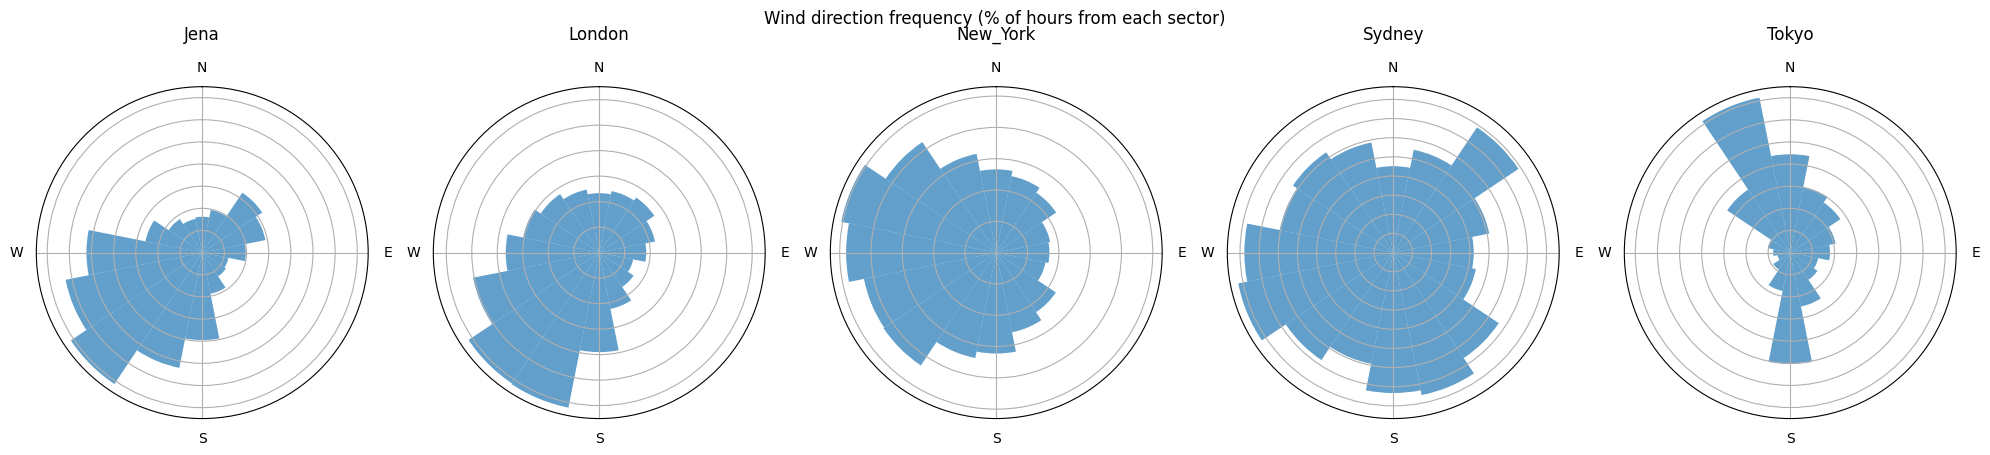

In [24]:
# 16 direction bins, centred on N, NNE, NE ... back round to N
n_bins = 16
bin_edges = np.linspace(0, 360, n_bins + 1)
centres = np.deg2rad(np.linspace(0, 360, n_bins, endpoint=False))
width = 2 * np.pi / n_bins

fig, axes = plt.subplots(1, 5, figsize=(20, 4.5), subplot_kw={'projection': 'polar'})
for ax, (city, df) in zip(axes, dfs.items()):
    counts, _ = np.histogram(df['wind_direction'].dropna(), bins=bin_edges)
    frac = 100 * counts / counts.sum()
    ax.bar(centres, frac, width=width, bottom=0, alpha=0.7)
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)   # clockwise, like a compass
    ax.set_title(city, pad=15)
    ax.set_xticks(np.deg2rad([0, 90, 180, 270]))
    ax.set_xticklabels(['N', 'E', 'S', 'W'])
    ax.set_yticklabels([])
fig.suptitle('Wind direction frequency (% of hours from each sector)')
plt.tight_layout()
plt.savefig(PLOTS + 'eda_wind_rose.png', dpi=150)
plt.show()

## wrap up

- all 5 cities are 100% complete, 87,672 hourly rows each (438,360 total), no imputation needed
- the cities are genuinely diverse, which is the whole point of RQ2:
  - Sydney's seasons are flipped (southern hemisphere) and its daily temps are negatively correlated with the four northern cities
  - the month x hour climatology fingerprints look completely different city to city
  - they also differ in annual range, humidity, precipitation regime (Tokyo's wet summer stands out) and prevailing wind direction
- no strong warming drift across the 10 years, so the chronological test split isn't biased by a trend
- autocorrelation stays high out to a week, so the 168h encoder window is reasonable
- master csv saved to processed/ for the modelling notebooks

So there's a real case both ways for RQ2: the cities are different enough that per-city models could specialise, but they share the same daily/seasonal structure so a pooled model with a city indicator might generalise just as well. The experiment in notebook 11 settles it.